

# Item based filtering
This approach is mostly preferred since the movie don't change much. We can rerun this model once a week unlike User based where we have to frequently run the model.

In this kernel, We look at the implementation of Item based filtering

In [6]:
import pandas as pd
import numpy as np

from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors

import matplotlib.pyplot as plt
import seaborn as sns



In [7]:
#read the dataset
movies = pd.read_csv("data/movies.csv") #read csv file in data/movies.csv
ratings = pd.read_csv("data/ratings.csv") #read csv file in data/ratings.csv

In [8]:
#print the head of the ratings to see some of its features
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


Ratings dataset has 
* userId - unique for each user
* movieId - using this feature ,we take the title of the movie from movies dataset
* rating - Ratings given by each user to all the movies using this we are going to predict the top 10 similar movies

In [9]:
#print the head of the movies to see some of its features\
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


Movie dataset has 
* movieId - once the recommendation is done, we get list of all similar movieId and get the title for each movie from this dataset. 
* genres -  which is not required for this filtering approach

In [10]:
#display the ratings from users per movies
#in other words, change the form of the table from what you saw in ratings.head()
#to something you could see as movie ratings per users
#so, transform the dataset of ratings to have the index as movieid.
final_dataset = ratings.pivot(index='movieId',columns='userId',values='rating')
final_dataset.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
movieId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,NaN,NaN,4.0,NaN,4.5,NaN,NaN,NaN,...,4.0,NaN,4.0,3.0,4.0,2.5,4.0,2.5,3.0,5.0
2,NaN,NaN,NaN,NaN,NaN,4.0,NaN,4.0,NaN,NaN,...,NaN,4.0,NaN,5.0,3.5,NaN,NaN,2.0,NaN,NaN
3,4.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# How should you handle missing values here?
#for now, just fill the NaN  as 0
final_dataset.fillna(0,inplace=True)
final_dataset.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
movieId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,0.0,0.0,4.0,0.0,4.5,0.0,0.0,0.0,...,4.0,0.0,4.0,3.0,4.0,2.5,4.0,2.5,3.0,5.0
2,0.0,0.0,0.0,0.0,0.0,4.0,0.0,4.0,0.0,0.0,...,0.0,4.0,0.0,5.0,3.5,0.0,0.0,2.0,0.0,0.0
3,4.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0


In a real world, ratings are very sparse and data points are mostly collected from very popular movies and highly engaged users. So we will reduce the noise by adding some filters and qualify the movies for the final dataset.
* To qualify a movie, minimum 10 users should have voted a movie.
* To qualify a user, minimum 50 movies should have voted by the user.


In [12]:
# Count the Number of Users Who Voted for Each Movie:
# Group the DataFrame by movieId and count the number of ratings for each movie.

no_user_voted = ratings.groupby('movieId')['rating'].agg('count')
no_movies_voted = ratings.groupby('userId')['rating'].agg('count')


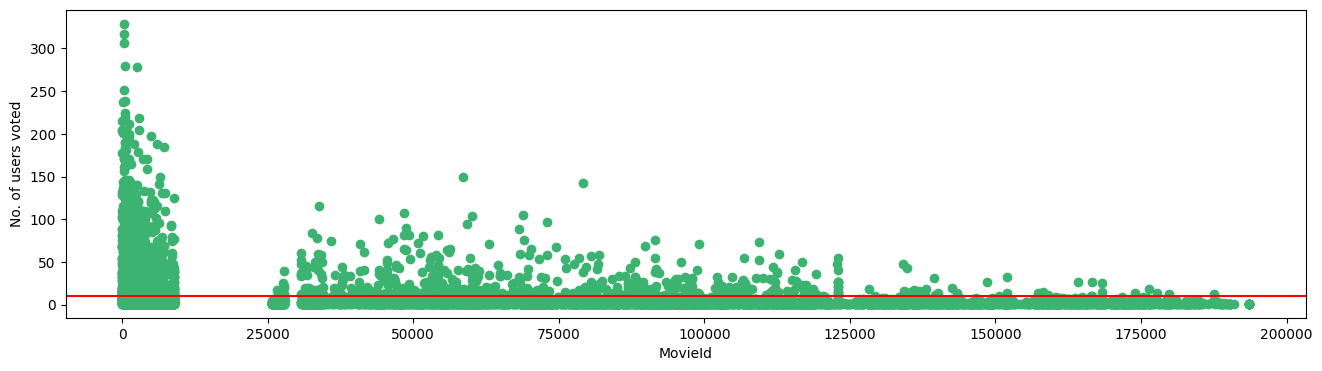

In [13]:
#Count the Number of Movies Each User Has Voted For:
#Group the DataFrame by userId and count the number of ratings each user has made.
no_user_voted = ratings.groupby('movieId')['rating'].agg('count')
no_movies_voted = ratings.groupby('userId')['rating'].agg('count')

f,ax = plt.subplots(1,1,figsize=(16,4))
# ratings['rating'].plot(kind='hist')
plt.scatter(no_user_voted.index,no_user_voted,color='mediumseagreen')
plt.axhline(y=10,color='r')
plt.xlabel('MovieId')
plt.ylabel('No. of users voted')
plt.show()

In [14]:
final_dataset = final_dataset.loc[no_user_voted[no_user_voted > 10].index,:]

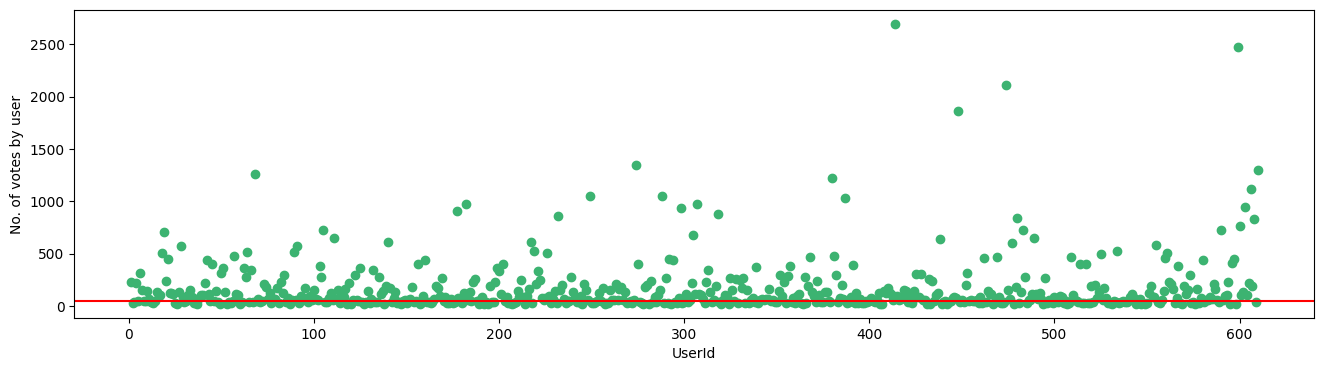

In [15]:


f,ax = plt.subplots(1,1,figsize=(16,4))
plt.scatter(no_movies_voted.index,no_movies_voted,color='mediumseagreen')
plt.axhline(y=50,color='r')
plt.xlabel('UserId')
plt.ylabel('No. of votes by user')
plt.show()

In [16]:
#now keep the movies that where voted by more than 10 users.
final_dataset = final_dataset.loc[:,no_movies_voted[no_movies_voted > 50].index]
final_dataset

userId,1,4,6,7,10,11,15,16,17,18,...,600,601,602,603,604,605,606,607,608,610
movieId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,0.0,4.5,0.0,0.0,2.5,0.0,4.5,3.5,...,2.5,4.0,0.0,4.0,3.0,4.0,2.5,4.0,2.5,5.0
2,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,...,4.0,0.0,4.0,0.0,5.0,3.5,0.0,0.0,2.0,0.0
3,4.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0
5,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.5,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0
6,4.0,0.0,4.0,0.0,0.0,5.0,0.0,0.0,0.0,4.0,...,0.0,0.0,3.0,4.0,3.0,0.0,0.0,0.0,0.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174055,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
176371,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
177765,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Our final_dataset has dimensions of **2121 * 378** where most of the values are sparse. I took only small dataset but for
original large dataset of movie lens which has more than **100000** features, this will sure hang our system when this has 
feed to model. To reduce the sparsity we use csr_matric scipy lib. I'll give an example how it works

In [17]:
sample = np.array([[0,0,3,0,0],[4,0,0,0,2],[0,0,0,0,1]])
sparsity = 1.0 - ( np.count_nonzero(sample) / float(sample.size) )
print(sparsity)

0.7333333333333334


In [18]:
csr_sample = csr_matrix(sample)
print(csr_sample)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 4 stored elements and shape (3, 5)>
  Coords	Values
  (0, 2)	3
  (1, 0)	4
  (1, 4)	2
  (2, 4)	1


* As you can see there is no sparse value in the csr_sample and values are assigned as rows and column index. for the 0th row and 2nd column , value is 3 . Look at the original dataset where the values at the right place. This is how it works using todense method you can take it back to original dataset.
* Most of the sklearn works with sparse matrix. surely this will improve our performance

In [19]:
csr_data = csr_matrix(final_dataset.values)
final_dataset.reset_index(inplace=True)

We use cosine distance metric which is very fast and preferable than pearson coefficient. Please don't use euclidean distance which will not work when the values are equidistant.

In [20]:
knn = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=20, n_jobs=-1)

In [21]:
knn = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=20, n_jobs=-1)
knn.fit(csr_data) #fit the sparse data

NearestNeighbors(algorithm='brute', metric='cosine', n_jobs=-1, n_neighbors=20)

In [22]:
def get_movie_recommendation(movie_name):
    n_movies_to_reccomend = 10
    movie_list = movies[movies['title'].str.contains(movie_name)]  
    if len(movie_list):        
        movie_idx= movie_list.iloc[0]['movieId']
        movie_idx = final_dataset[final_dataset['movieId'] == movie_idx].index[0]
        
        distances , indices = knn.kneighbors(csr_data[movie_idx],n_neighbors=n_movies_to_reccomend+1)    
        rec_movie_indices = sorted(list(zip(indices.squeeze().tolist(),distances.squeeze().tolist())),\
                               key=lambda x: x[1])[:0:-1]
        
        recommend_frame = []
        
        for val in rec_movie_indices:
            movie_idx = final_dataset.iloc[val[0]]['movieId']
            idx = movies[movies['movieId'] == movie_idx].index
            recommend_frame.append({'Title':movies.iloc[idx]['title'].values[0],'Distance':val[1]})
        df = pd.DataFrame(recommend_frame,index=range(1,n_movies_to_reccomend+1))
        return df
    
    else:
        
        return "No movies found. Please check your input"

In [23]:
get_movie_recommendation('Iron Man')

,Title,Distance
1,Up (2009),0.368857
2,Guardians of the Galaxy (2014),0.368758
3,Watchmen (2009),0.368558
4,Star Trek (2009),0.366029
5,Batman Begins (2005),0.362759
6,Avatar (2009),0.310893
7,Iron Man 2 (2010),0.307492
8,WALL·E (2008),0.298138
9,"Dark Knight, The (2008)",0.285835
10,"Avengers, The (2012)",0.285319


In [24]:
get_movie_recommendation('Memento')



,Title,Distance
1,American Beauty (1999),0.389346
2,American History X (1998),0.388615
3,Pulp Fiction (1994),0.386235
4,"Lord of the Rings: The Return of the King, The...",0.371622
5,Kill Bill: Vol. 1 (2003),0.350167
6,"Lord of the Rings: The Two Towers, The (2002)",0.348358
7,Eternal Sunshine of the Spotless Mind (2004),0.346196
8,"Matrix, The (1999)",0.326215
9,"Lord of the Rings: The Fellowship of the Ring,...",0.316777
10,Fight Club (1999),0.272380


In [25]:
from sklearn.cluster import KMeans
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np

In [26]:
# Elbow Method for Optimal K in K-Means
def elbow_method(max_clusters=15):
    inertia = []
    for k in range(1, max_clusters + 1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(csr_data)
        inertia.append(kmeans.inertia_)
    
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, max_clusters + 1), inertia, marker='o')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Inertia')
    plt.title('Elbow Method For Optimal K')
    plt.show()

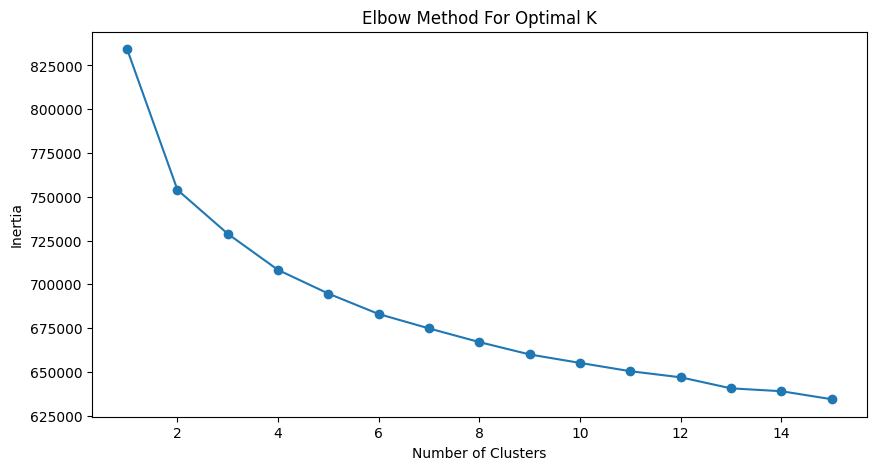

In [27]:
elbow_method(max_clusters=15)

In [28]:
# K-Means Clustering Model
def train_kmeans(n_clusters=10):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(csr_data)
    final_dataset['Cluster'] = clusters
    return kmeans

def get_movie_recommendation_kmeans(movie_name, kmeans_model):
    movie_list = movies[movies['title'].str.contains(movie_name, case=False, na=False)]
    
    if len(movie_list):
        movie_idx = movie_list.iloc[0]['movieId']
        movie_idx = final_dataset[final_dataset['movieId'] == movie_idx].index[0]
        movie_cluster = final_dataset.iloc[movie_idx]['Cluster']
        
        similar_movies = final_dataset[final_dataset['Cluster'] == movie_cluster]
        recommend_movies = similar_movies.sample(n=10, random_state=42) if len(similar_movies) > 10 else similar_movies
        
        recommend_frame = [{
                             'Title': movies[movies['movieId'] == row['movieId']].iloc[0]['title'],
                             'Cluster': row['Cluster']
                            
                            } 
                            for _, row in recommend_movies.iterrows()
                           ]
        
        df = pd.DataFrame(recommend_frame, index=range(1, len(recommend_frame) + 1))
        return df
    else:
        return "No movies found. Please check your input."
    
    


In [29]:
# Train K-Means Model
kmeans_model = train_kmeans(n_clusters=10)
kmeans_model.fit(csr_data)

KMeans(n_clusters=10, n_init=10, random_state=42)

In [30]:
#add a column to show the cluster of each movie

cluster_labels = kmeans_model.labels_
final_dataset['Cluster'] = cluster_labels
final_dataset

userId,movieId,1,4,6,7,10,11,15,16,17,...,601,602,603,604,605,606,607,608,610,Cluster
0,1,4.0,0.0,0.0,4.5,0.0,0.0,2.5,0.0,4.5,...,4.0,0.0,4.0,3.0,4.0,2.5,4.0,2.5,5.0,6
1,2,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.0,0.0,5.0,3.5,0.0,0.0,2.0,0.0,2
2,3,4.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,5
3,5,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,5
4,6,4.0,0.0,4.0,0.0,0.0,5.0,0.0,0.0,0.0,...,0.0,3.0,4.0,3.0,0.0,0.0,0.0,0.0,5.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2116,174055,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
2117,176371,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9
2118,177765,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
2119,179819,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9


In [31]:
train_kmeans(n_clusters=10)
get_movie_recommendation_kmeans('Iron Man',kmeans_model)

,Title,Cluster
1,Black Swan (2010),3.0
2,Star Wars: Episode III - Revenge of the Sith (...,3.0
3,Interstellar (2014),3.0
4,X2: X-Men United (2003),3.0
5,Burn After Reading (2008),3.0
6,Men in Black II (a.k.a. MIIB) (a.k.a. MIB 2) (...,3.0
7,Children of Men (2006),3.0
8,The Butterfly Effect (2004),3.0
9,Hot Fuzz (2007),3.0
10,Black Hawk Down (2001),3.0


In [32]:
train_kmeans(n_clusters=10)
get_movie_recommendation_kmeans('Memento',kmeans_model)

,Title,Cluster
1,"Beautiful Mind, A (2001)",8.0
2,"Lord of the Rings: The Two Towers, The (2002)",8.0
3,Shrek 2 (2004),8.0
4,Kill Bill: Vol. 2 (2004),8.0
5,Shrek (2001),8.0
6,"Lord of the Rings: The Return of the King, The...",8.0
7,Finding Nemo (2003),8.0
8,Ocean's Eleven (2001),8.0
9,"Dark Knight, The (2008)",8.0
10,Donnie Darko (2001),8.0


In [33]:
def plot_knn_vs_kmeans(movie_name, kmeans_model):
    knn_recommendations = get_movie_recommendation(movie_name)
    kmeans_recommendations = get_movie_recommendation_kmeans(movie_name, kmeans_model)

    if isinstance(knn_recommendations, str) or isinstance(kmeans_recommendations, str):
        print("No recommendations found for the given movie name.")
        return
    
    knn_titles = knn_recommendations['Title'].tolist()
    kmeans_titles = kmeans_recommendations['Title'].tolist()

    # Combine unique movie titles from both methods
    all_titles = list(set(knn_titles + kmeans_titles))

    if not all_titles:
        print("No common movie recommendations to compare.")
        return

    # Assign ranking based on occurrence
    fallback_rank = len(all_titles) + 1
    knn_ranks = [knn_titles.index(title) + 1 if title in knn_titles else fallback_rank for title in all_titles]
    kmeans_ranks = [kmeans_titles.index(title) + 1 if title in kmeans_titles else fallback_rank for title in all_titles]

    plt.figure(figsize=(10, 6))
    width = 0.4  # Width of bars

    # Plot KNN results
    plt.barh(all_titles, knn_ranks, height=width, color='blue', alpha=0.6, label='KNN')

    # Plot K-Means results
    plt.barh(all_titles, kmeans_ranks, height=width, color='red', alpha=0.6, label='K-Means')

    plt.xlabel("Ranking (Lower is better)")
    plt.ylabel("Movie Titles")
    plt.title(f"Comparison of KNN vs K-Means for '{movie_name}'")
    plt.legend()
    plt.gca().invert_yaxis()  # Invert Y-axis to show rank 1 at the top
    plt.show()


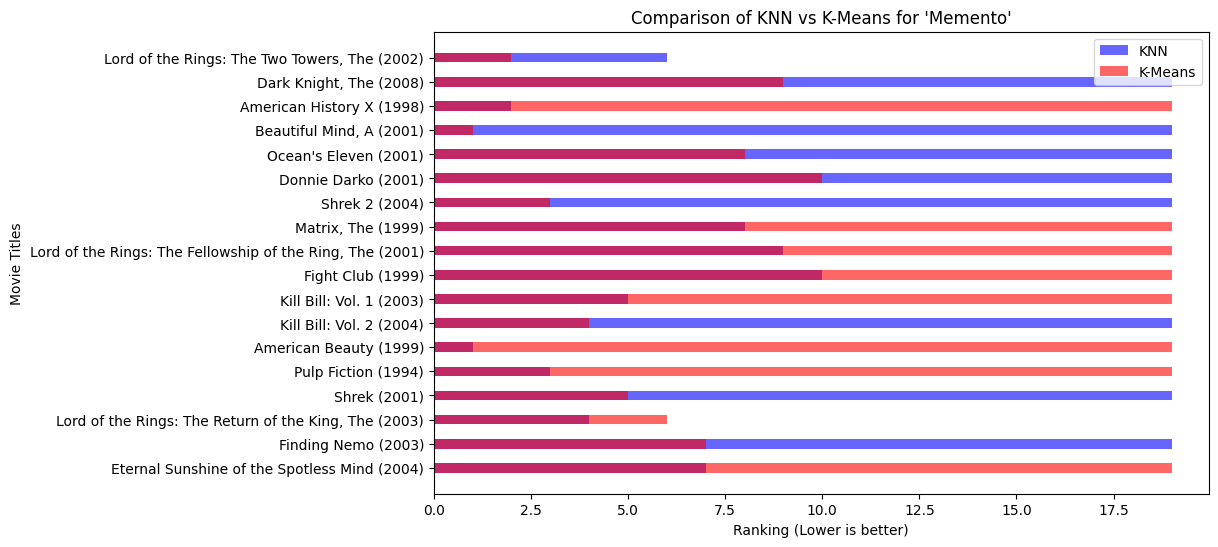

In [34]:
plot_knn_vs_kmeans('Memento',kmeans_model)


Our model works perfectly predicting the recommendation based on user behaviour and past search. So we conclude our 
collaborative filtering here.
